In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
font_path = "C:/Windows/Fonts/malgun.ttf"
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [29]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv('../data/smooth_pattern.csv')
df

,date,cake_pack,protein_800g,tteokbokki_2,tteokbokki_4,daechang,gopchang,towel_cake,strawberry,udon
0,2022-01-01,84,30,40,236,50,51,58,77,35
1,2022-01-02,91,29,35,213,39,60,75,60,33
2,2022-01-03,94,32,40,288,44,55,72,68,33
3,2022-01-04,98,33,37,238,32,64,78,67,35
4,2022-01-05,102,29,39,236,44,57,74,55,39
...,...,...,...,...,...,...,...,...,...,...
1091,2024-12-27,83,28,34,235,35,59,61,75,33
1092,2024-12-28,83,29,30,278,29,65,50,83,33
1093,2024-12-29,90,30,34,275,29,63,61,70,38
1094,2024-12-30,118,34,27,258,33,65,61,89,30


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1096 non-null   object
 1   cake_pack     1096 non-null   int64 
 2   protein_800g  1096 non-null   int64 
 3   tteokbokki_2  1096 non-null   int64 
 4   tteokbokki_4  1096 non-null   int64 
 5   daechang      1096 non-null   int64 
 6   gopchang      1096 non-null   int64 
 7   towel_cake    1096 non-null   int64 
 8   strawberry    1096 non-null   int64 
 9   udon          1096 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 85.8+ KB


In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
def plot_separate_time_series(df, cols):
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(cols, 1):
        plt.subplot(9, 1, i)
        plt.plot(df['date'], df[col], label=col, color='tab:blue')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.title(f'{col} over time')
        plt.grid(True)
        plt.tight_layout()

    plt.show()

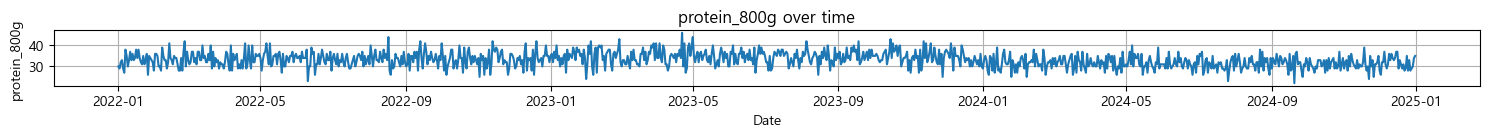

In [9]:
plot_separate_time_series(df, ['protein_800g'])

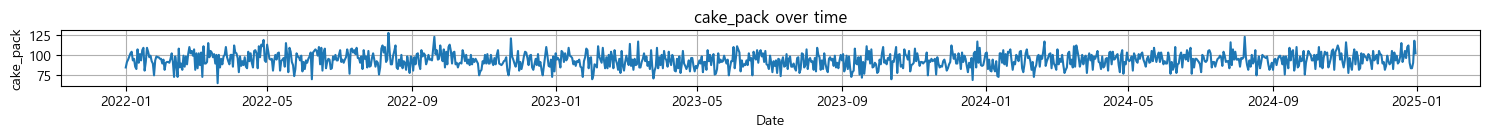

In [10]:
plot_separate_time_series(df, ['cake_pack'])

# Auto_ARIMA
- p,d,q는 고정하고, 슬라이딩마다 새로 학습(fit)하고, window size만큼 예측하는 방식

In [32]:
def sliding_arima_forecast_fixed_order(df, col, test_ratio=0.2, window_size=7, seasonal=False):
    df = df.set_index('date')
    series = df[col].fillna(0)

    # (1) Train/Test split
    split_idx = int(len(series) * (1 - test_ratio))
    train, test = series[:split_idx], series[split_idx:]

    # (2) 초기 train 데이터로 p, d, q 고정
    model_init = auto_arima(train, seasonal=seasonal, stepwise=True, suppress_warnings=True)
    p, d, q = model_init.order
    print(f"[{col}] 초기 고정된 ARIMA Order: ({p},{d},{q})")

    preds = []
    history = train.copy()

    # (3) 슬라이딩 예측 시작
    for i in range(0, len(test), window_size):
        end_idx = min(i + window_size, len(test))

        model = ARIMA(history, order=(p, d, q))
        model_fit = model.fit()

        pred = model_fit.forecast(steps=end_idx - i)
        preds.extend(pred)

        # history에 새로운 test 구간 추가
        history = pd.concat([history, test.iloc[i:end_idx]])

    # (4) 결과 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(test.index, test, label='Actual', color='black')
    plt.plot(test.index, preds, label='Forecast', color='red')
    plt.title(f'{col} - Sliding ARIMA Forecast (fixed order)')
    plt.legend()
    plt.grid(True)
    plt.show()

[['udon']] 초기 고정된 ARIMA Order: (1,1,2)


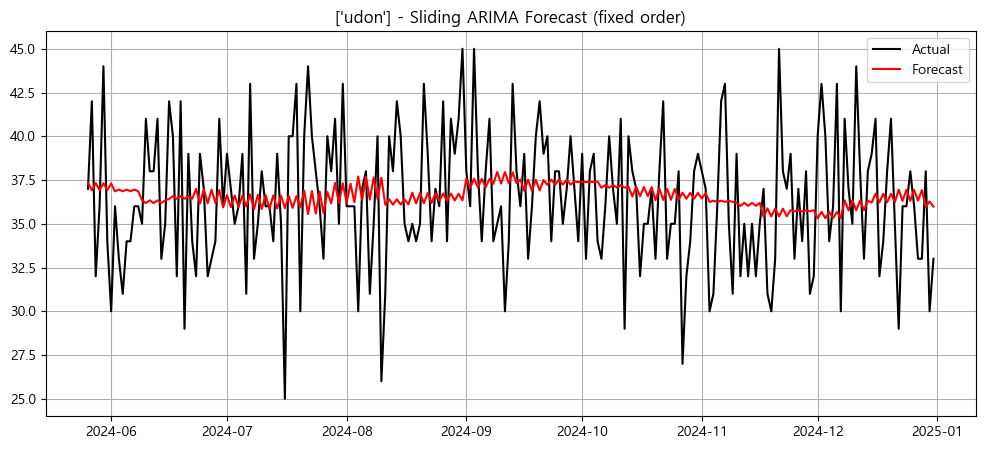

In [33]:
sliding_arima_forecast_fixed_order(df, ['udon'])                                

[['cake_pack']] 초기 고정된 ARIMA Order: (0,1,1)


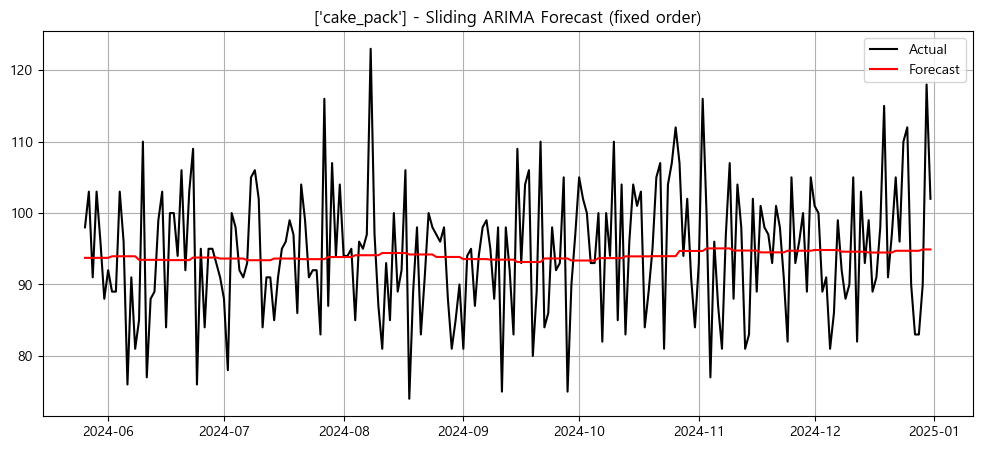

In [34]:
sliding_arima_forecast_fixed_order(df, ['cake_pack'])

[['daechang']] 초기 고정된 ARIMA Order: (0,1,1)


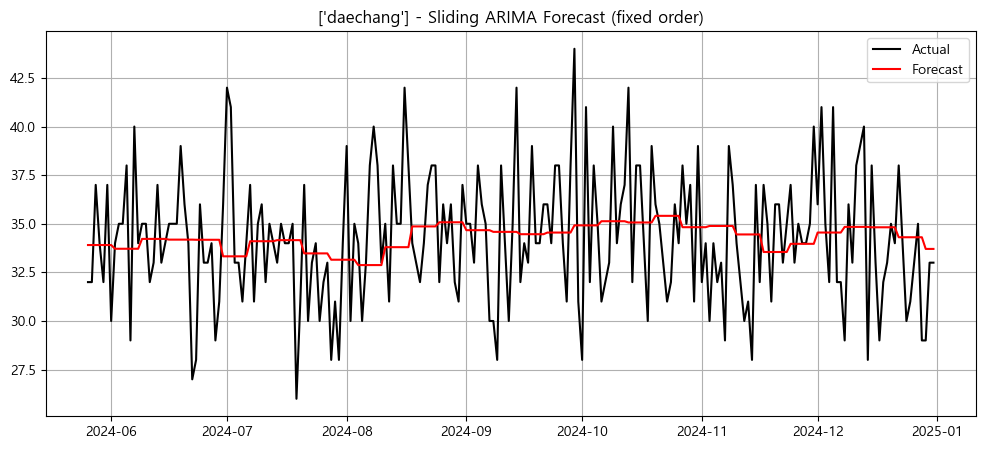

In [35]:
sliding_arima_forecast_fixed_order(df, ['daechang'])

[['gopchang']] 초기 고정된 ARIMA Order: (0,1,2)


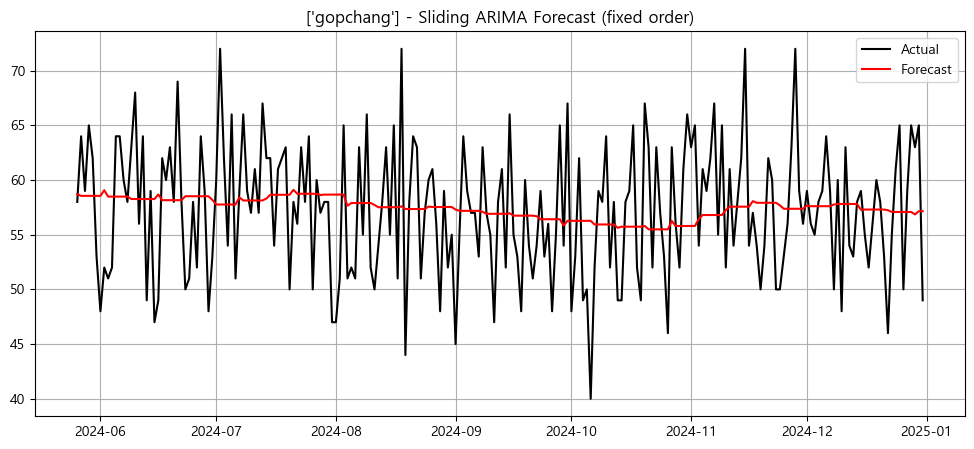

In [36]:
sliding_arima_forecast_fixed_order(df, ['gopchang'])

[['strawberry']] 초기 고정된 ARIMA Order: (0,1,1)


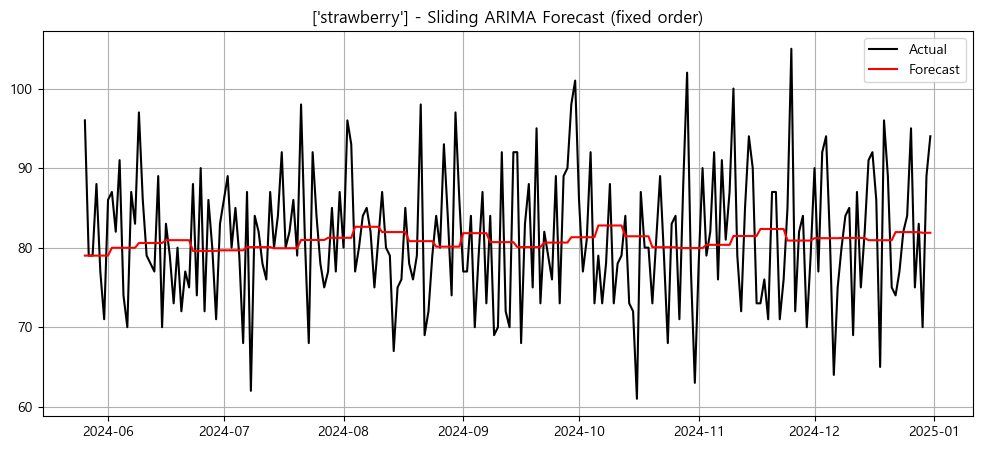

In [37]:
sliding_arima_forecast_fixed_order(df, ['strawberry'])